## **Import Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

## **Loading Dataset**

In [5]:
df= pd.read_csv('Data/Restaurant_sales.csv', parse_dates=['date'])
df

,date,item,sales,is_weekend,is_holiday,is_festival,promo_active,temperature_celsius,rainfall_mm
0,2022-01-01,Burger,224,1,0,1,0,21.6,0.3
1,2022-01-01,Pizza,164,1,0,1,0,21.6,0.3
2,2022-01-01,Pasta,149,1,0,1,0,21.6,0.3
3,2022-01-01,Salad,98,1,0,1,0,21.6,0.3
4,2022-01-02,Burger,112,1,0,0,0,22.2,0.2
...,...,...,...,...,...,...,...,...,...
2915,2023-12-30,Salad,81,1,0,0,1,16.4,0.2
2916,2023-12-31,Burger,191,1,0,0,1,18.1,3.4
2917,2023-12-31,Pizza,144,1,0,0,1,18.1,3.4
2918,2023-12-31,Pasta,129,1,0,0,1,18.1,3.4


## **EDA**

In [6]:
print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (2920, 9)

Column dtypes:
date                   datetime64[ns]
item                           object
sales                           int64
is_weekend                      int64
is_holiday                      int64
is_festival                     int64
promo_active                    int64
temperature_celsius           float64
rainfall_mm                   float64
dtype: object

First 5 rows:


,date,item,sales,is_weekend,is_holiday,is_festival,promo_active,temperature_celsius,rainfall_mm
0,2022-01-01,Burger,224,1,0,1,0,21.6,0.3
1,2022-01-01,Pizza,164,1,0,1,0,21.6,0.3
2,2022-01-01,Pasta,149,1,0,1,0,21.6,0.3
3,2022-01-01,Salad,98,1,0,1,0,21.6,0.3
4,2022-01-02,Burger,112,1,0,0,0,22.2,0.2


In [7]:
# ── Statistical summary ───
print("=== Descriptive Statistics ===")
print(df.groupby('item')['sales'].describe().round(2))

# ── Check for missing values ───
print("=== Missing Values ===")
print(df.isnull().sum())
print("\n No missing values expected since we generated this data.")

# ── Check for duplicate rows ──
dupes = df.duplicated(subset=['date','item']).sum()
print(f"Duplicate (date, item) pairs: {dupes}")

=== Descriptive Statistics ===
        count    mean    std   min   25%   50%    75%    max
item                                                        
Burger  730.0  102.02  43.67  46.0  76.0  91.0  116.0  495.0
Pasta   730.0   63.82  26.61  29.0  48.0  58.0   73.0  329.0
Pizza   730.0   82.63  35.32  39.0  62.0  75.0   95.0  483.0
Salad   730.0   43.55  17.44  18.0  33.0  40.0   50.0  212.0
=== Missing Values ===
date                   0
item                   0
sales                  0
is_weekend             0
is_holiday             0
is_festival            0
promo_active           0
temperature_celsius    0
rainfall_mm            0
dtype: int64

 No missing values expected since we generated this data.
Duplicate (date, item) pairs: 0


## **Focus on one Item: Burger**

##### we model each menu item separately. we start with Burger as the primary focus.( Filter One Item (Burger))

In [8]:
df = df[df['item'] == 'Burger']
df = df.sort_values('date')
df.set_index('date', inplace=True)

print("\nDate Range:", df.index.min(), "to", df.index.max())


Date Range: 2022-01-01 00:00:00 to 2023-12-31 00:00:00


## **Time-Series Trend Visualization**

#### Temperature, Rainfall, Promo & Festival

#### Plot 1: Sales Trend

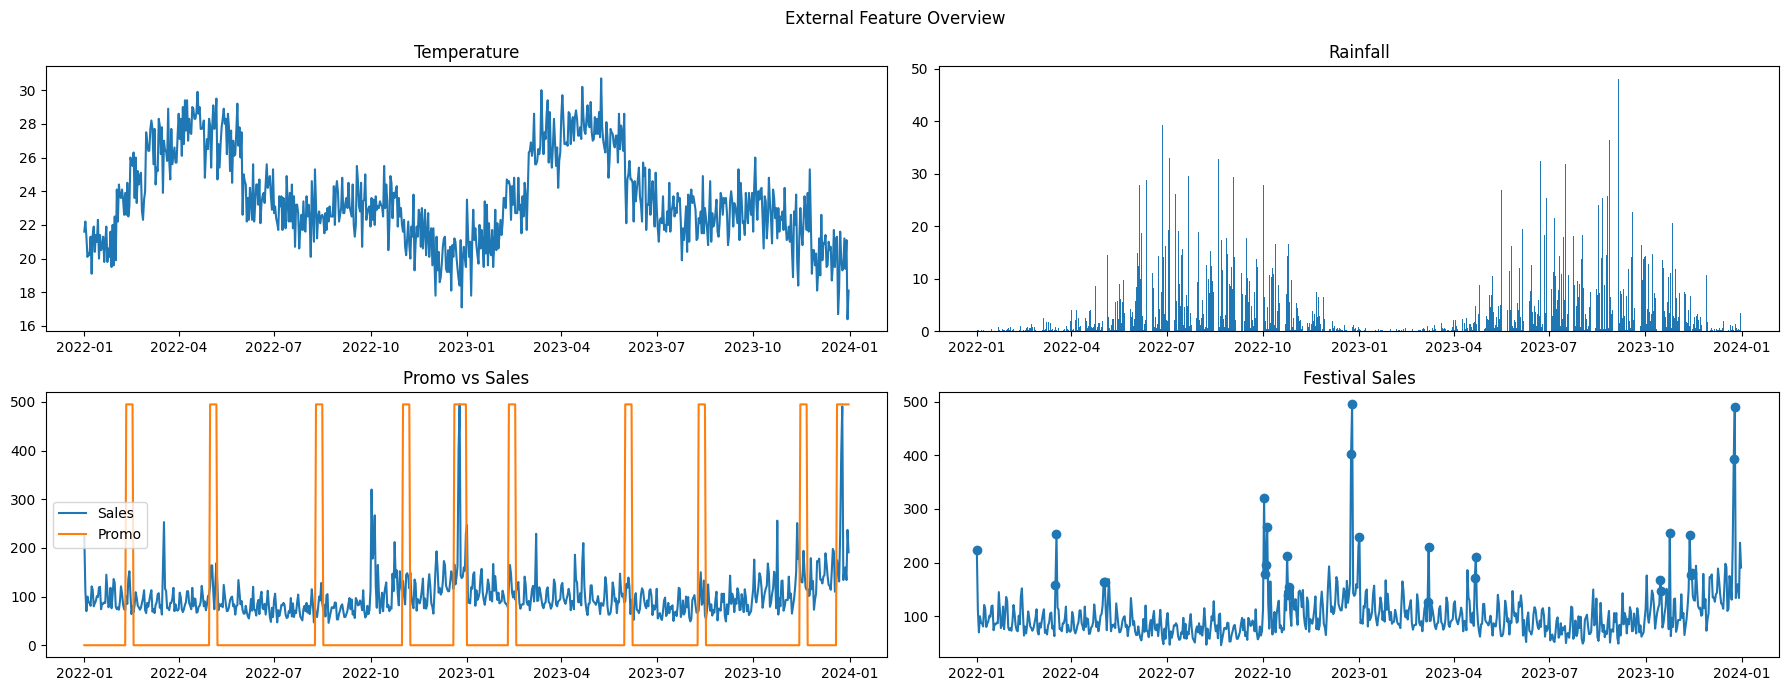

In [9]:
import matplotlib.pyplot as plt

burger = df[df['item'] == 'Burger']
burger = burger.sort_values('date')

plt.figure(figsize=(18,7))

#  1. Temperature
plt.subplot(2,2,1)
plt.plot(burger.index, burger['temperature_celsius'])
plt.title("Temperature")

# 2. Rainfall
plt.subplot(2,2,2)
plt.bar(burger.index, burger['rainfall_mm'])
plt.title("Rainfall")

# 3. Promo vs Sales
plt.subplot(2,2,3)
plt.plot(burger.index, burger['sales'], label='Sales')
plt.plot(burger.index, burger['promo_active'] * burger['sales'].max(), label='Promo')
plt.title("Promo vs Sales")
plt.legend()


# 4. Festival Days
plt.subplot(2,2,4)
plt.plot(burger.index, burger['sales'])
festival = burger[burger['is_festival'] == 1]
plt.scatter(festival.index, festival['sales'])
plt.title("Festival Sales")

plt.suptitle("External Feature Overview")
plt.tight_layout()

##### Aggregate total daily sales across all items

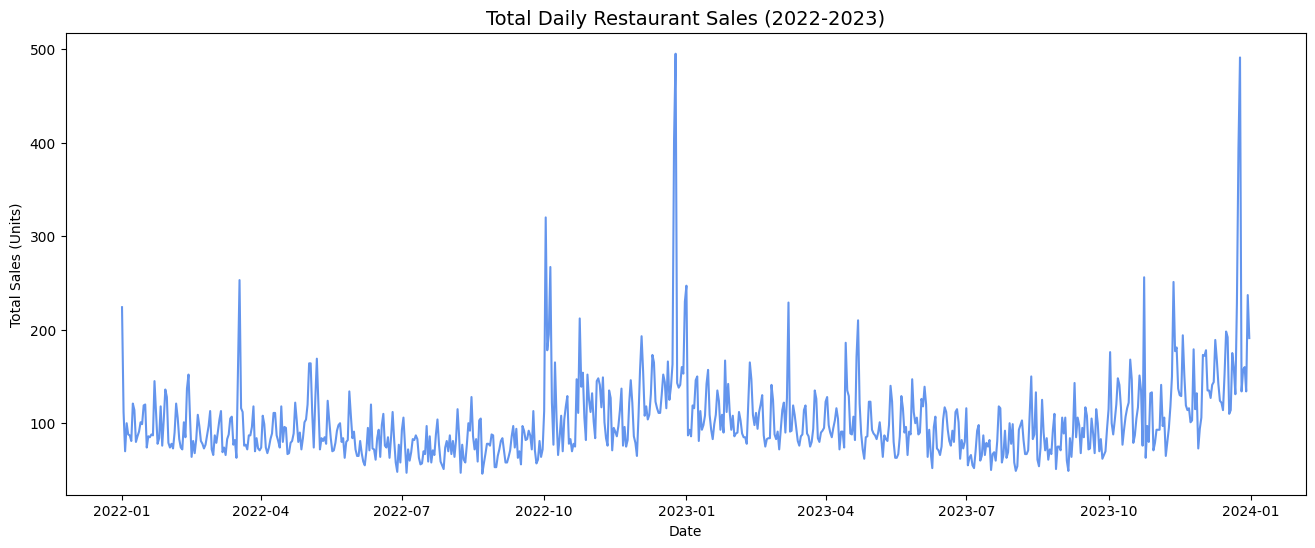

In [10]:
daily_sales = df.groupby('date')['sales'].sum().reset_index()
plt.figure(figsize=(16, 6))
sns.lineplot(data=daily_sales, x='date', y='sales', color='cornflowerblue')
plt.title('Total Daily Restaurant Sales (2022-2023)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Sales (Units)')
plt.show()

## **Seasonality Analysis**

#### Plot 2: Average sales by day of week

In [19]:
print(df.index)
print(df.columns.tolist())

DatetimeIndex(['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04',
               '2022-01-05', '2022-01-06', '2022-01-07', '2022-01-08',
               '2022-01-09', '2022-01-10',
               ...
               '2023-12-22', '2023-12-23', '2023-12-24', '2023-12-25',
               '2023-12-26', '2023-12-27', '2023-12-28', '2023-12-29',
               '2023-12-30', '2023-12-31'],
              dtype='datetime64[ns]', name='date', length=730, freq=None)
['item', 'sales', 'is_weekend', 'is_holiday', 'is_festival', 'promo_active', 'temperature_celsius', 'rainfall_mm']


date
2022-01-02    168.000000
2022-01-09     94.428571
2022-01-16     99.428571
2022-01-23     96.714286
2022-01-30    103.428571
Freq: W-SUN, Name: sales, dtype: float64


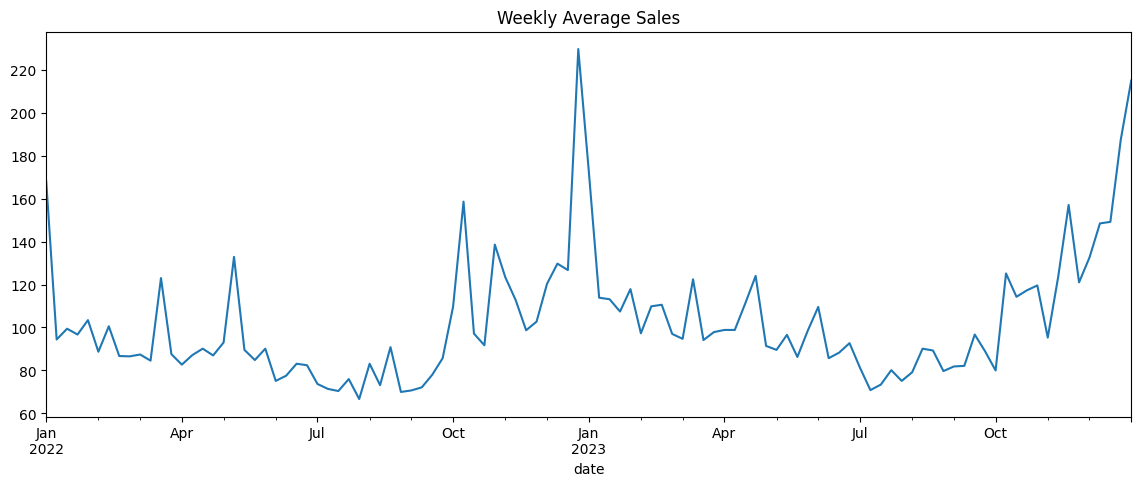

date
2022-01-31    102.354839
2022-02-28     90.392857
2022-03-31     93.677419
2022-04-30     88.733333
2022-05-31     99.258065
Freq: ME, Name: sales, dtype: float64


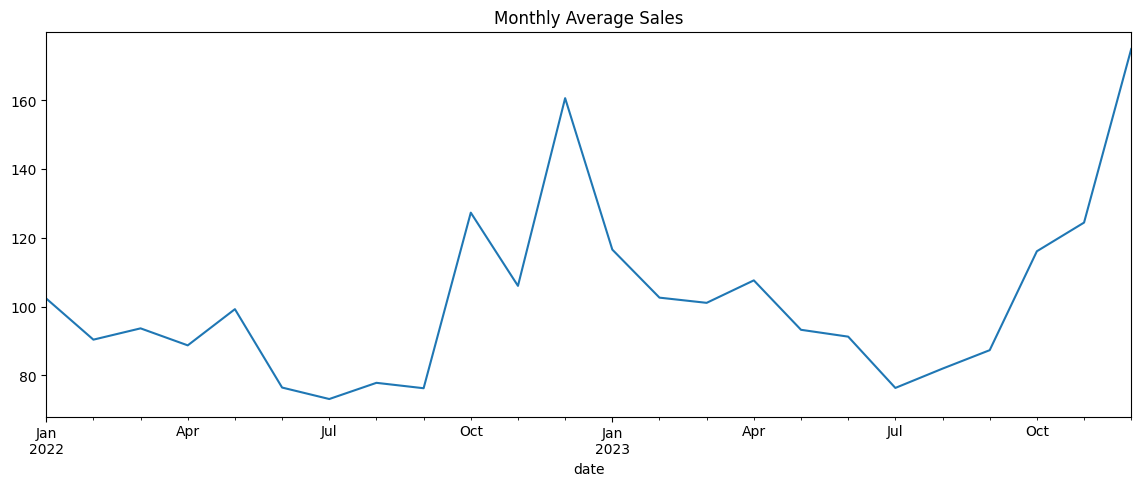

In [20]:
# Weekly Average Sales
weekly_avg = df.resample('W')['sales'].mean()
print(weekly_avg.head())
weekly_avg.plot(title='Weekly Average Sales', figsize=(14,5))
plt.show()

# Monthly Average Sales
monthly_avg = df.resample('M')['sales'].mean()
print(monthly_avg.head())
monthly_avg.plot(title='Monthly Average Sales', figsize=(14,5))
plt.show()

### Temperature vs Sales scatter

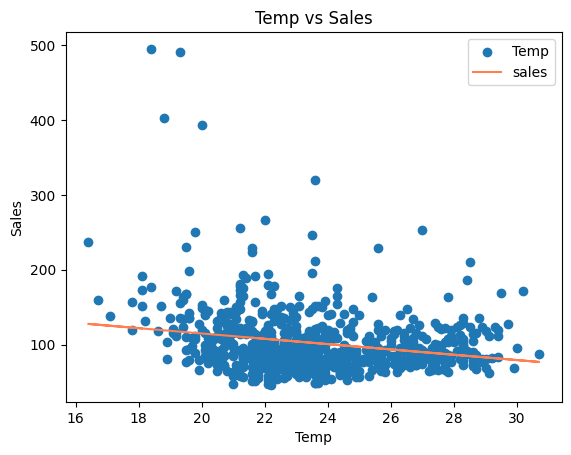

In [15]:
import numpy as np
plt.scatter(burger['temperature_celsius'], burger['sales'],label="Temp")
x = burger['temperature_celsius']
y = burger['sales']
plt.plot(x, np.poly1d(np.polyfit(x, y, 1))(x), color='coral',label="sales")
plt.title("Temp vs Sales")
plt.xlabel("Temp")
plt.ylabel("Sales")
plt.legend()
plt.show()

#### Plot 3: **Time-Series Decomposition**

Decompose into: Trend + Seasonality + Residual

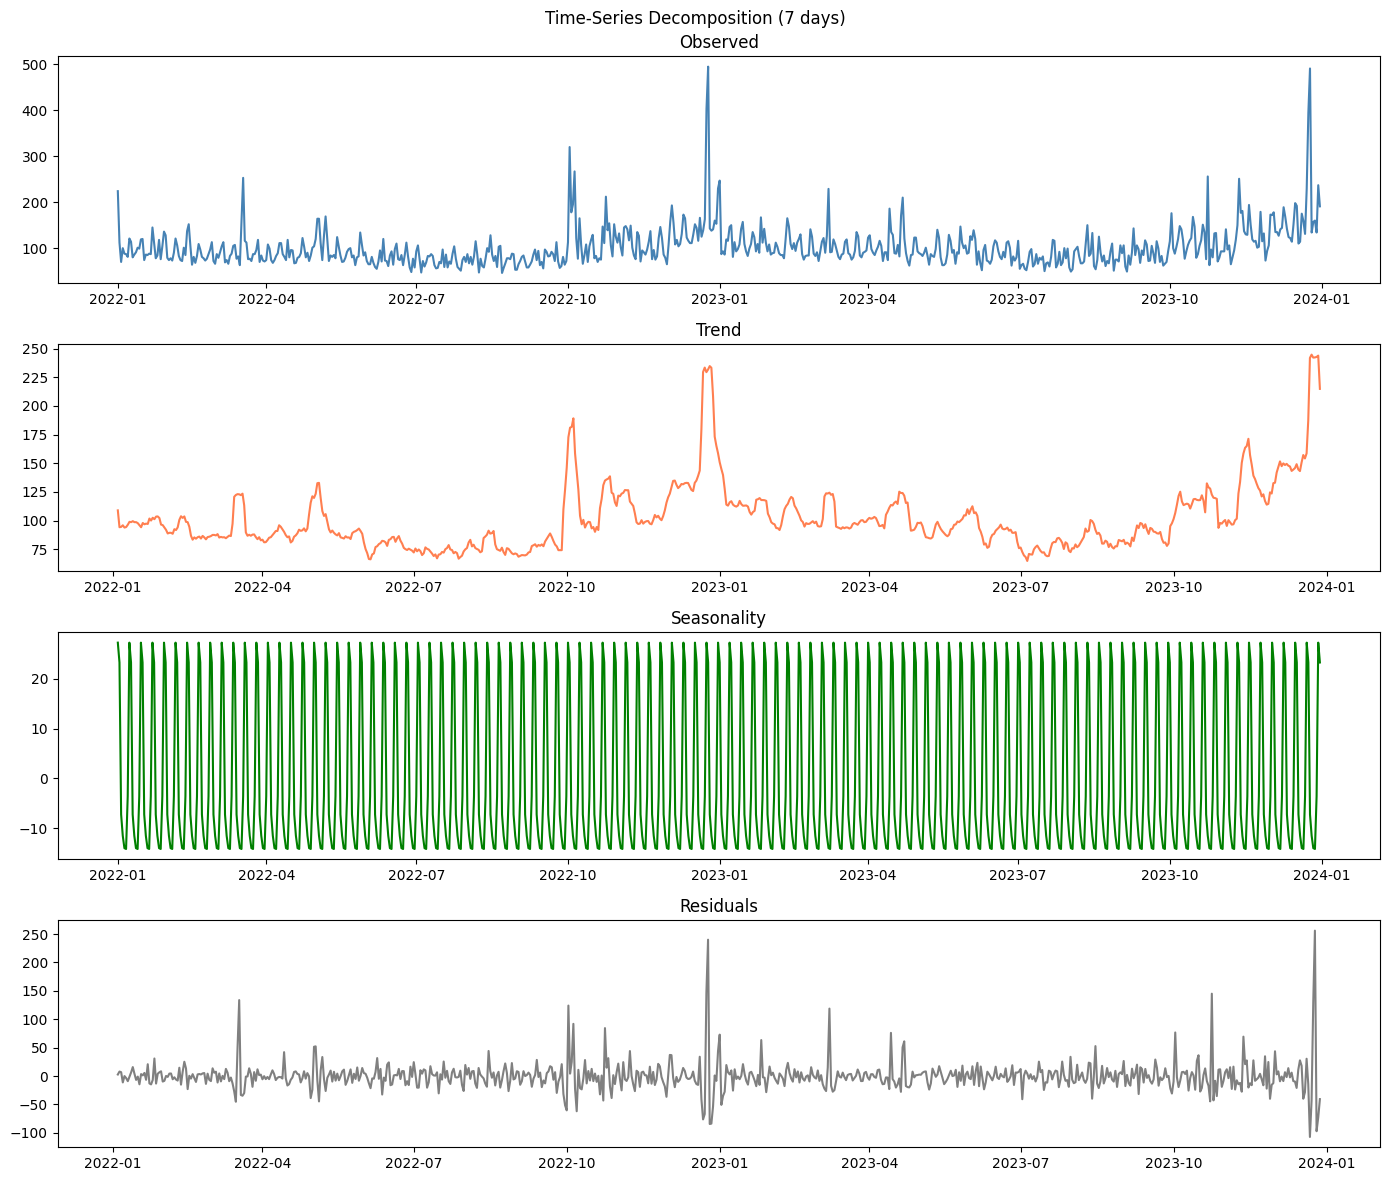

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import os
import pandas as pd

burger_df = df[df['item'] == 'Burger'].copy() # Filter for 'Burger' items

# Decompose using the prepared burger_df
decomp = seasonal_decompose(burger_df['sales'], model='additive', period=7)

plt.figure(figsize=(14, 12))

# Observed
plt.subplot(4,1,1)
plt.plot(decomp.observed, color='steelblue')
plt.title('Observed')

# Trend
plt.subplot(4,1,2)
plt.plot(decomp.trend, color='coral')
plt.title('Trend')

# Seasonality
plt.subplot(4,1,3)
plt.plot(decomp.seasonal, color='green')
plt.title('Seasonality')

# Residuals
plt.subplot(4,1,4)
plt.plot(decomp.resid, color='gray')
plt.title('Residuals')

plt.suptitle('Time-Series Decomposition (7 days)')
plt.tight_layout()

# Save
os.makedirs('reports', exist_ok=True)
plt.savefig('reports/03_decomposition.png')

plt.show()


## **Autocorrelation Analysis**

#### Plot 4: ACF and PACF

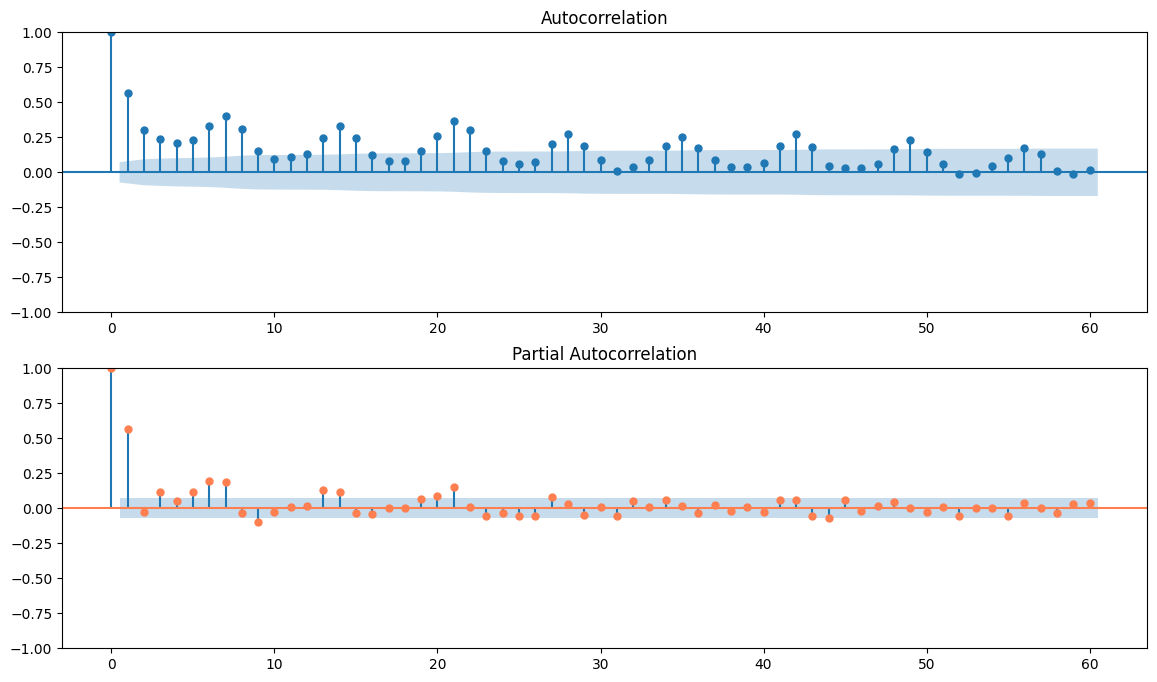

In [22]:
fig, ax = plt.subplots(2,1, figsize=(14,8))
plot_acf(df['sales'], lags=60, ax=ax[0])
plot_pacf(df['sales'], lags=60, ax=ax[1],color='coral')

plt.show()

## **Holiday Effect Analysis**

#### Plot 5: Holiday vs Non-Holiday sales distribution

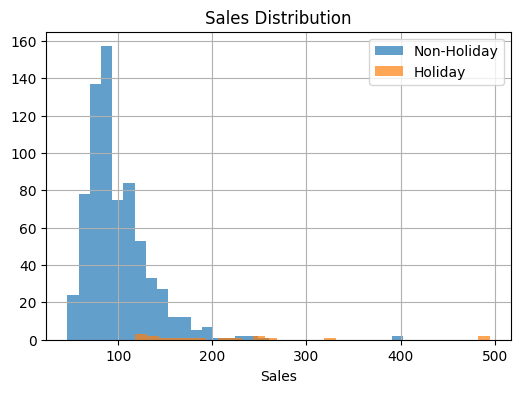

===Average comparison===
Holiday avg: 225.3
Non-Holiday avg: 99.1


In [23]:
plt.figure(figsize=(6,4))
df[df['is_holiday']==0]['sales'].hist(bins=30, alpha=0.7, label='Non-Holiday')
df[df['is_holiday']==1]['sales'].hist(bins=30, alpha=0.7, label='Holiday')
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.legend()
plt.show()

print("===Average comparison===")
holiday_avg = df[df['is_holiday']==1]['sales'].mean()
non_holiday_avg = df[df['is_holiday']==0]['sales'].mean()
print("Holiday avg:", round(holiday_avg,1))
print("Non-Holiday avg:", round(non_holiday_avg,1))


## **All Items Comparison**

#### Plot 6: All Items Comparison

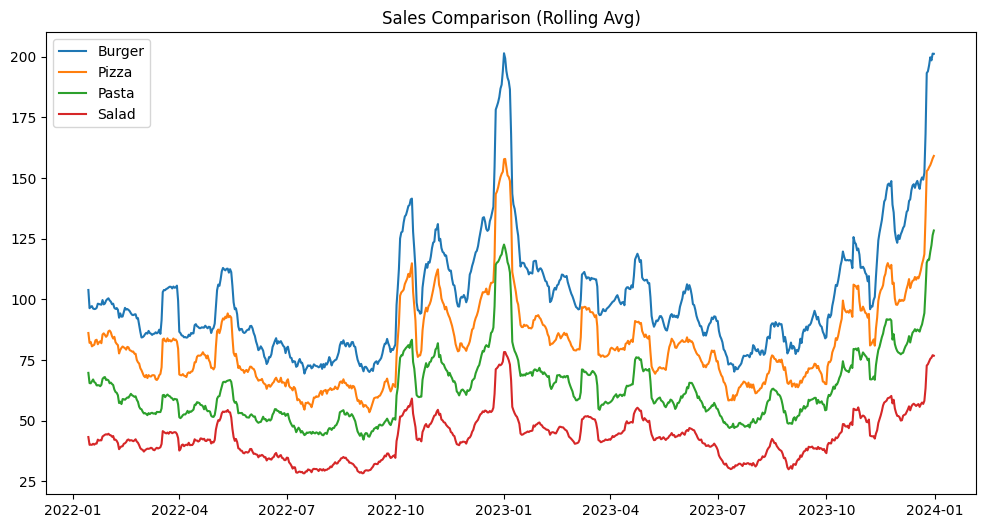

In [25]:
full_df = pd.read_csv("Data/Restaurant_sales.csv",parse_dates=['date'])

items = ['Burger', 'Pizza', 'Pasta', 'Salad']

plt.figure(figsize=(12,6))
for item in items:
    temp = full_df[full_df['item'] == item]
    temp = temp.sort_values('date')
    rolling = temp['sales'].rolling(14).mean()
    plt.plot(temp['date'], rolling, label=item)
plt.title("Sales Comparison (Rolling Avg)")
plt.legend()
plt.show()